# Lab 4. Autoencoders on FashionMNIST

This notebook solves the assignment with a fully connected and a convolutional autoencoder.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

try:
    from ipywidgets import interactive
except ImportError:
    interactive = None

from matplotlib.offsetbox import AnnotationBbox, TextArea

try:
    from sklearn.decomposition import PCA
except ImportError:
    PCA = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [4]:
# constants
IMG_CHANNELS = 1
IMG_SIZE = 28
INP_DIM = IMG_SIZE * IMG_SIZE
latent_space_dim = 4
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
BATCH_SIZE = 128

# image transformations
transform = transforms.Compose([
    transforms.ToTensor(),
])

img_shape = (IMG_CHANNELS, IMG_SIZE, IMG_SIZE)

In [5]:
# Dataset
trainset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
testset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Dataloader
trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

labeldict = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

images, labels = next(iter(trainloader))
print(images.shape)
print(labels.shape)

torch.Size([128, 1, 28, 28])
torch.Size([128])


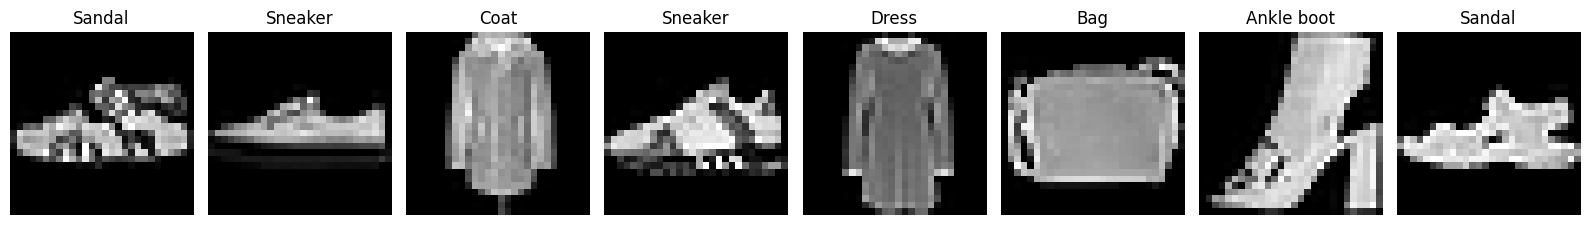

In [6]:
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(labeldict[int(labels[i])])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [7]:
class AutoEncoder(nn.Module):
    def __init__(self, img_shape, inp_dim, hidden_dim):
        super(AutoEncoder, self).__init__()
        self.img_shape = img_shape
        self.encoder = nn.Sequential(
            nn.Linear(inp_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, inp_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(batch_size, *self.img_shape)

    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

    def decode(self, x_latent):
        decoded = self.decoder(x_latent)
        return decoded.view(x_latent.size(0), *self.img_shape)

In [8]:
class ConvAutoEncoder(nn.Module):
    def __init__(self, img_shape, hidden_dim):
        super().__init__()
        self.img_shape = img_shape
        self.feature_encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        self.to_latent = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_dim)
        )
        self.from_latent = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32 * 7 * 7),
            nn.ReLU()
        )
        self.feature_decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

    def encode(self, x):
        features = self.feature_encoder(x)
        return self.to_latent(features)

    def decode(self, x_latent):
        x = self.from_latent(x_latent)
        x = x.view(x_latent.size(0), 32, 7, 7)
        return self.feature_decoder(x)

In [9]:
def train_autoencoder(model, train_loader, criterion, optimizer, num_epochs, device):
    train_loss = []
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for batch, _ in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            outputs = model(batch)
            loss = criterion(outputs, batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_loss.append(epoch_loss)
        print(f'Epoch [{epoch + 1}/{num_epochs}] Loss: {epoch_loss:.6f}')
    return train_loss


def plot_train_loss(train_loss, title, filename=None):
    plt.figure(figsize=(8, 4))
    plt.plot(train_loss)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    if filename is not None:
        plt.savefig(filename, bbox_inches='tight')
    plt.show()


def display_img(img, img_size=28):
    plt.imshow(img.detach().cpu().numpy().reshape((img_size, img_size)), cmap='gray')
    plt.axis('off')
    plt.show()


@torch.no_grad()
def show_reconstructions(model, dataloader, title, num_images=8):
    model.eval()
    inputs, _ = next(iter(dataloader))
    inputs = inputs[:num_images].to(device)
    outputs = torch.clamp(model(inputs), 0.0, 1.0)

    fig, axes = plt.subplots(2, num_images, figsize=(2 * num_images, 4))
    fig.suptitle(title)
    for i in range(num_images):
        axes[0, i].imshow(inputs[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(outputs[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=12)
    axes[1, 0].set_ylabel('Reconstructed', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


@torch.no_grad()
def plot_latent(model, dataloader, title, max_points=2000):
    model.eval()
    latent_chunks = []
    label_chunks = []
    seen = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        encoded = model.encode(inputs)
        latent_chunks.append(encoded.cpu())
        label_chunks.append(labels.cpu())
        seen += inputs.size(0)
        if seen >= max_points:
            break

    coords = torch.cat(latent_chunks, dim=0)[:max_points].numpy()
    classes = torch.cat(label_chunks, dim=0)[:max_points].numpy()

    if coords.shape[1] > 2:
        if PCA is not None:
            coords_2d = PCA(n_components=2).fit_transform(coords)
        else:
            coords_2d = coords[:, :2]
    else:
        coords_2d = coords

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_title(title)
    scatter = ax.scatter(coords_2d[:, 0], coords_2d[:, 1], c=classes, cmap='tab10', s=15)
    plt.colorbar(scatter, ax=ax)

    for i in range(10):
        mask = classes == i
        if np.any(mask):
            class_center = np.mean(coords_2d[mask], axis=0)
            text = TextArea(f'{labeldict[i]} ({i})')
            ab = AnnotationBbox(text, class_center, xycoords='data', frameon=True)
            ax.add_artist(ab)

    plt.show()


@torch.no_grad()
def latent_range(model, dataloader, max_batches=20):
    model.eval()
    latents = []
    for batch_idx, (inputs, _) in enumerate(dataloader):
        inputs = inputs.to(device)
        latents.append(model.encode(inputs).cpu())
        if batch_idx + 1 >= max_batches:
            break

    latents = torch.cat(latents, dim=0)
    bound = float(latents.abs().max().item())
    bound = max(bound, 1.0)
    return -bound, bound


def decode_from_latent(model, z_values):
    model.eval()
    z = torch.tensor([z_values], dtype=torch.float32, device=device)
    decoded = model.decode(z)
    img = decoded[0, 0].detach().cpu().numpy()
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


def interactive_decoder(model, slider_min=-3.0, slider_max=3.0, step=0.1):
    model.eval()

    if interactive is None:
        print('ipywidgets is not installed. Run `%pip install ipywidgets` and restart the kernel to enable sliders.')
        print('Fallback: showing a decoded image for latent vector [0.0, 0.0, 0.0, 0.0].')
        decode_from_latent(model, [0.0, 0.0, 0.0, 0.0])
        return None

    def plot(z1=0.0, z2=0.0, z3=0.0, z4=0.0):
        decode_from_latent(model, [z1, z2, z3, z4])

    interactive_plot = interactive(
        plot,
        z1=(slider_min, slider_max, step),
        z2=(slider_min, slider_max, step),
        z3=(slider_min, slider_max, step),
        z4=(slider_min, slider_max, step)
    )
    output = interactive_plot.children[-1]
    output.layout.height = '350px'
    return interactive_plot

## Fully Connected AutoEncoder

In [ ]:
fc_model = AutoEncoder(
    img_shape=img_shape,
    inp_dim=INP_DIM,
    hidden_dim=latent_space_dim
).to(device)

criterion = nn.MSELoss()  # nn.BCELoss()
optimizer = optim.Adam(fc_model.parameters(), lr=LEARNING_RATE)

fc_train_loss = train_autoencoder(
    fc_model,
    trainloader,
    criterion,
    optimizer,
    NUM_EPOCHS,
    device
)

PATH = f'fashion_AE_{latent_space_dim}.pth'
torch.save(fc_model.state_dict(), PATH)
PATH

Epoch [1/20] Loss: 0.037055
Epoch [2/20] Loss: 0.022546
Epoch [3/20] Loss: 0.021053
Epoch [4/20] Loss: 0.020288
Epoch [5/20] Loss: 0.019795
Epoch [6/20] Loss: 0.019442
Epoch [7/20] Loss: 0.019180
Epoch [8/20] Loss: 0.018966
Epoch [9/20] Loss: 0.018786
Epoch [10/20] Loss: 0.018602
Epoch [11/20] Loss: 0.018470
Epoch [12/20] Loss: 0.018348
Epoch [13/20] Loss: 0.018233
Epoch [14/20] Loss: 0.018137
Epoch [15/20] Loss: 0.018053
Epoch [16/20] Loss: 0.017944
Epoch [17/20] Loss: 0.017883
Epoch [18/20] Loss: 0.017808
Epoch [19/20] Loss: 0.017749
Epoch [20/20] Loss: 0.017683


'fashion_AE_4.pth'

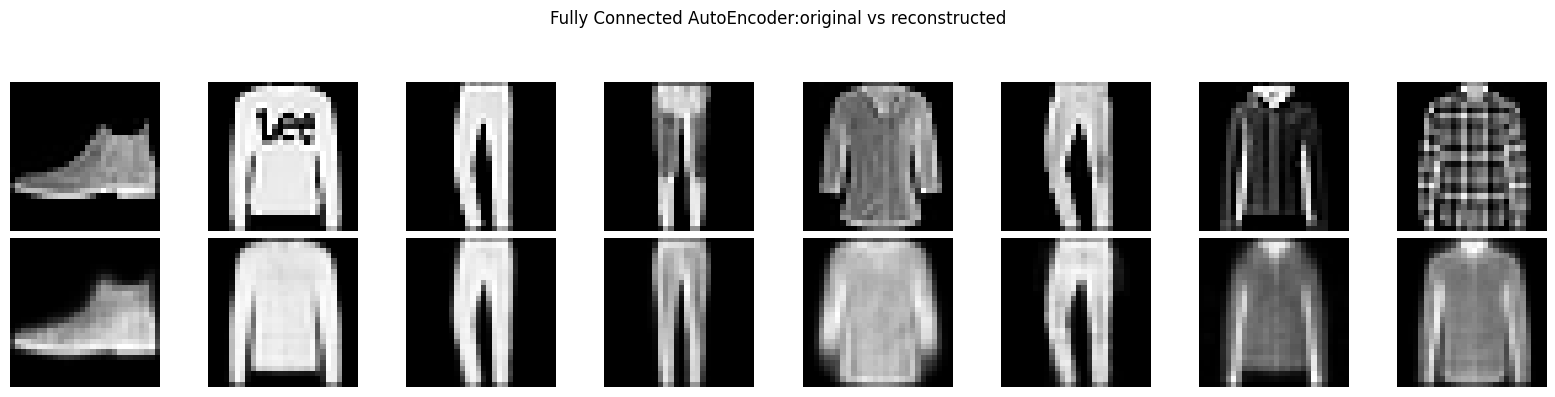

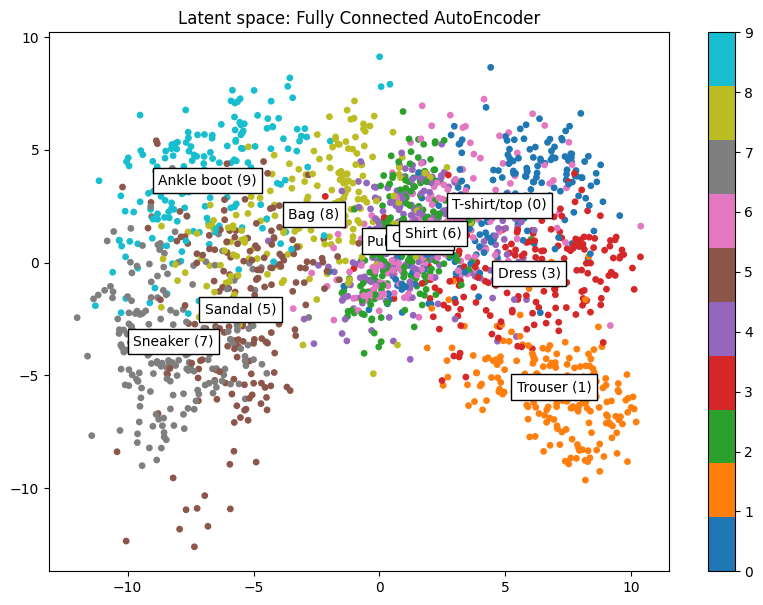

In [10]:
fc_model = AutoEncoder(
      img_shape=img_shape,
      inp_dim=INP_DIM,
      hidden_dim=4
  ).to(device)

fc_model.load_state_dict(torch.load('/home/bargomix/Documents/secondcourse/PAC/semister4/24944_Bezborodov_N_A_PAC/lab4/fashion_AE_4.pth', map_location=device))
fc_model.eval()

fc_slider_min, fc_slider_max = latent_range(fc_model, testloader)
fc_widget = interactive_decoder(fc_model, slider_min=fc_slider_min,
slider_max=fc_slider_max, step=0.1)
fc_widget

show_reconstructions(fc_model, testloader, 'Fully Connected AutoEncoder:original vs reconstructed')

plot_latent(fc_model, testloader, 'Latent space: Fully Connected AutoEncoder')

In [11]:
plot_train_loss(fc_train_loss, 'Train Loss: Fully Connected AutoEncoder', 'deep_ae_fashionmnist_loss.png')
show_reconstructions(fc_model, testloader, 'Fully Connected AutoEncoder: original vs reconstructed')
plot_latent(fc_model, testloader, 'Latent space: Fully Connected AutoEncoder')

NameError: name 'fc_train_loss' is not defined

In [ ]:
fc_slider_min, fc_slider_max = latent_range(fc_model, testloader)
fc_widget = interactive_decoder(fc_model, slider_min=fc_slider_min, slider_max=fc_slider_max, step=0.1)
fc_widget

## Convolutional AutoEncoder

In [ ]:
conv_model = ConvAutoEncoder(
    img_shape=img_shape,
    hidden_dim=latent_space_dim
).to(device)

criterion = nn.MSELoss()  # nn.BCELoss()
optimizer = optim.Adam(conv_model.parameters(), lr=LEARNING_RATE)

conv_train_loss = train_autoencoder(
    conv_model,
    trainloader,
    criterion,
    optimizer,
    NUM_EPOCHS,
    device
)

PATH = f'fashion_conv_AE_{latent_space_dim}.pth'
torch.save(conv_model.state_dict(), PATH)
PATH

In [ ]:
plot_train_loss(conv_train_loss, 'Train Loss: Convolutional AutoEncoder', 'conv_ae_fashionmnist_loss.png')
show_reconstructions(conv_model, testloader, 'Convolutional AutoEncoder: original vs reconstructed')
plot_latent(conv_model, testloader, 'Latent space: Convolutional AutoEncoder')